In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

First 5 Rows:
   Student_ID  Math  Science  English    Average Result Grade
0           1    71       60       59  63.333333   Pass     C
1           2    66       94       53  71.000000   Pass     B
2           3    63       67       72  67.333333   Pass     C
3           4    82       42       68  64.000000   Pass     C
4           5   100       70       65  78.333333   Pass     B

Highest Average Marks:
89.33333333333333

Lowest Average Marks:
50.666666666666664

Class Average:
69.02666666666666

Pass Students:
50

Fail Students:
0


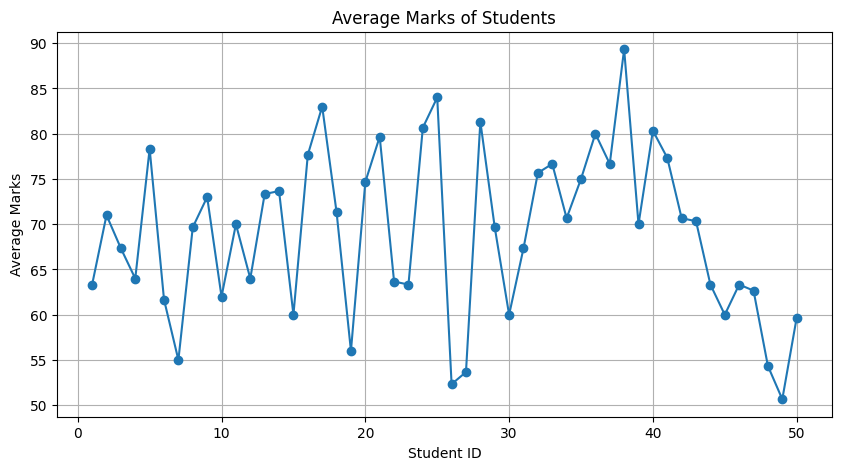

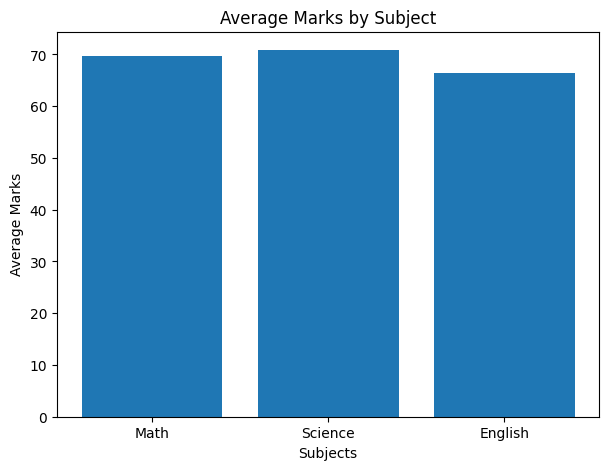

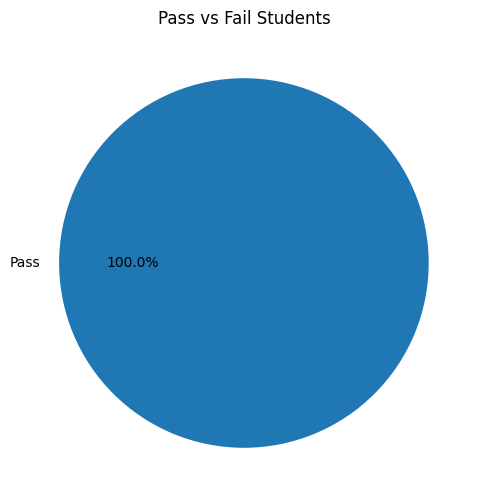

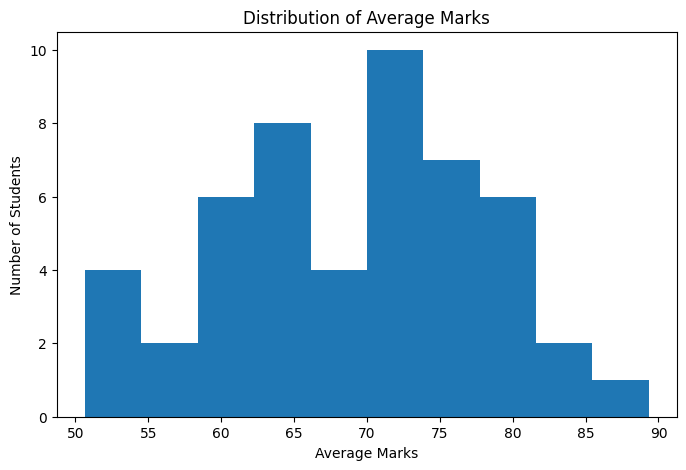

In [2]:
## Student Performance Analysis
## Using , Numpy , Pandas & Matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

students = 50

math_marks = np.random.randint(40, 101, students) ## generate 50 random integers between 40 to 100
science_marks = np.random.randint(40, 101, students)
english_marks = np.random.randint(40, 101, students)

df = pd.DataFrame({
    'Student_ID': range(1, students + 1), ## student id like 1,2,3,...,50
    'Math': math_marks,
    'Science': science_marks,
    'English': english_marks
})

df['Average'] = (df['Math'] + df['Science'] + df['English']) / 3
df['Result'] = np.where(df['Average'] >= 50, 'Pass', 'Fail') ## it checks condition ,, np.where(condition, true_value, false_value)

def assign_grade(avg):
    if avg >= 85:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 50:
        return 'C'
    else:
        return 'F'

df['Grade'] = df['Average'].apply(assign_grade)

print("First 5 Rows:")
print(df.head())

print("\nHighest Average Marks:")
print(df['Average'].max())

print("\nLowest Average Marks:")
print(df['Average'].min())

print("\nClass Average:")
print(df['Average'].mean())

print("\nPass Students:")
print((df['Result'] == 'Pass').sum())

print("\nFail Students:")
print((df['Result'] == 'Fail').sum())

plt.figure(figsize=(10,5))
plt.plot(df['Student_ID'], df['Average'], marker='o')
plt.title('Average Marks of Students')
plt.xlabel('Student ID')
plt.ylabel('Average Marks')
plt.grid(True)
plt.show()

subject_averages = [ ## for bar graph
    df['Math'].mean(),
    df['Science'].mean(),
    df['English'].mean()
]

subjects = ['Math', 'Science', 'English']

plt.figure(figsize=(7,5))
plt.bar(subjects, subject_averages)
plt.title('Average Marks by Subject')
plt.xlabel('Subjects')
plt.ylabel('Average Marks')
plt.show()

result_counts = df['Result'].value_counts() ## for pie chart

plt.figure(figsize=(6,6))
plt.pie(
    result_counts,
    labels=result_counts.index,
    autopct='%1.1f%%'
)
plt.title('Pass vs Fail Students')
plt.show()

plt.figure(figsize=(8,5)) ## for histogram
plt.hist(df['Average'], bins=10)
plt.title('Distribution of Average Marks')
plt.xlabel('Average Marks')
plt.ylabel('Number of Students')
plt.show()